# Neuron Segmentation Pipeline

**Pipeline steps:**
1. Load data
2. Preprocess (motion correction → background subtraction → dF/F)
3. Segmention (Correlation vs. Cellpose)
4. Extract activity traces
5. Visualisation

In [1]:
import sys
sys.path.insert(0, "..")

import numpy as np
import matplotlib.pyplot as plt

## 1. Load Data

Calcium imaging data comes as a temporal stack: a sequence of 2D frames recorded over time. Each frame captures fluorescence intensity when a neuron fires, its calcium indicator brightens briefly.

The data is stored as either AVI (8-bit video) or TIF (16-bit raw sensor data). We load it into a NumPy array of shape `(T, H, W)` time × height × width.

In [2]:
from src.data_loading import load_data, summarise

DATA_PATH = "../data/6s.tif"

stack = load_data(DATA_PATH)
summarise(stack, DATA_PATH)

- ../data/6s.tif -
  shape : (360, 200, 214)
  dtype : float32
  min   : 1100.0000
  max   : 1691.0000
  p1    : 1100.0000
  p99   : 1137.0000


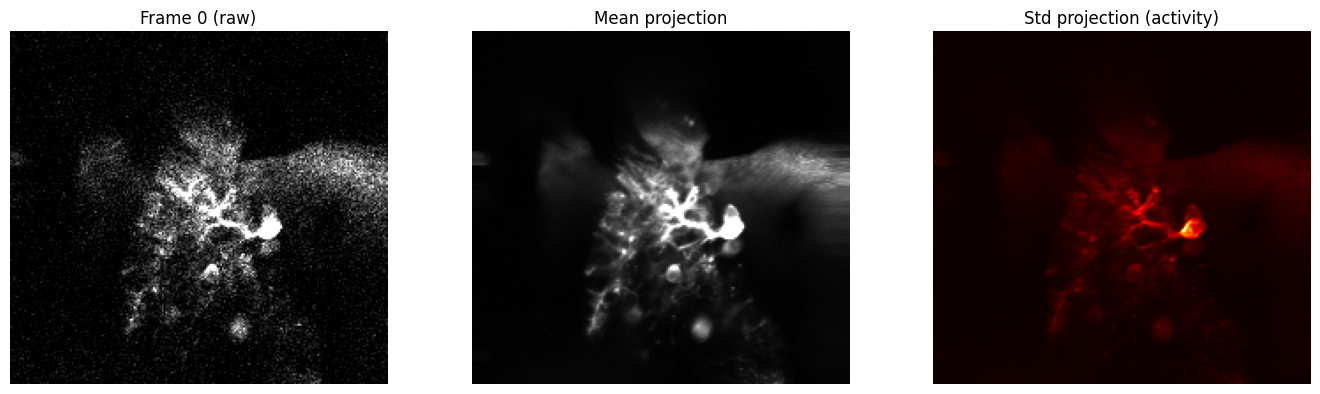

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

p1, p99 = np.percentile(stack, [1, 99])

axes[0].imshow(stack[0], cmap="gray", vmin=p1, vmax=p99)
axes[0].set_title("Frame 0 (raw)")

axes[1].imshow(np.mean(stack, axis=0), cmap="gray", vmin=p1, vmax=p99)
axes[1].set_title("Mean projection")

axes[2].imshow(np.std(stack, axis=0), cmap="hot")
axes[2].set_title("Std projection (activity)")

for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()

## 2. Preprocessing

Raw calcium imaging data has three problems that must be corrected before segmentation:

### Motion Correction
The tissue drifts slightly during recording (breathing, heartbeat). A neuron at pixel (100, 50) in frame 1 might shift to (101, 51) later. We align every frame to the mean using phase cross-correlation.

### Background Subtraction
The raw fluorescence contains non-neuronal signal: uneven illumination, out-of-focus haze. We estimate this background with a large Gaussian blur and subtract it, isolating the local neuron signal.

### dF/F Normalization
Different neurons have different baseline brightness. dF/F (delta-F over F) normalizes each pixel by its own baseline, converting raw intensity to relative change. This makes signals comparable across neurons.

In [4]:
from src.data_preprocessing import preprocess, motion_correct, subtract_background, compute_dff

motion_cor = motion_correct(stack)
summarise(motion_cor, "Motion Correction")
subtract_bg = subtract_background(motion_cor)
summarise(subtract_bg, "Background Subtraction")
compute_df = compute_dff(subtract_bg)
summarise(compute_df, "dF/F Normalisation")
dff = preprocess(stack)
summarise(dff, "Preprocessed dF/F")

- Motion Correction -
  shape : (360, 200, 214)
  dtype : float32
  min   : 1088.7845
  max   : 1687.0127
  p1    : 1099.4482
  p99   : 1137.0090
- Background Subtraction -
  shape : (360, 200, 214)
  dtype : float32
  min   : -17.6458
  max   : 579.0267
  p1    : -6.4119
  p99   : 30.5577
- dF/F Normalisation -
  shape : (360, 200, 214)
  dtype : float32
  min   : -1.0000
  max   : 20.0000
  p1    : -0.4025
  p99   : 4.6979
Motion correction ...
Background subtraction ...
Computing dF/F ...
Done.
- Preprocessed dF/F -
  shape : (360, 200, 214)
  dtype : float32
  min   : -1.0000
  max   : 20.0000
  p1    : -0.4025
  p99   : 4.6979


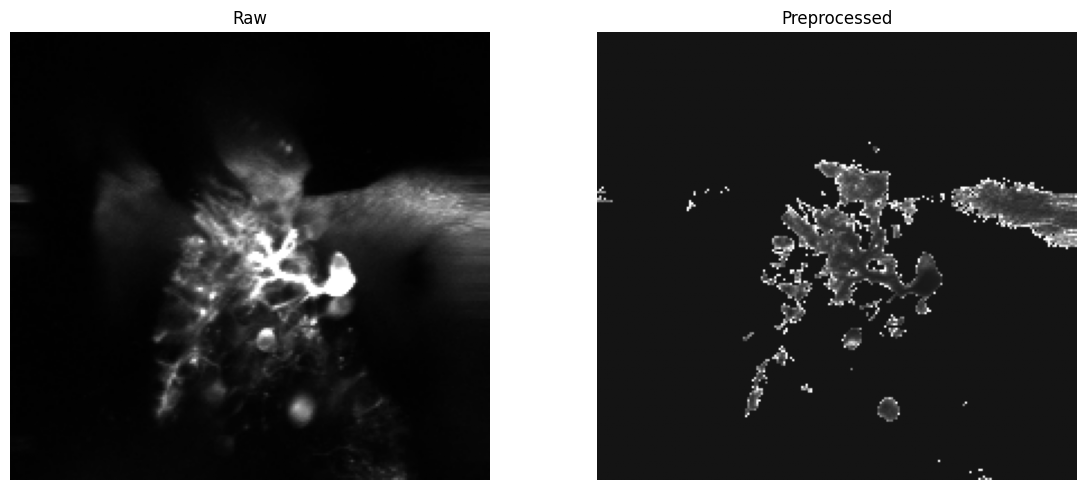

In [5]:
# Before vs after preprocessing
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

p1, p99 = np.percentile(stack, [1, 99])
axes[0].imshow(np.mean(stack, axis=0), cmap="gray", vmin=p1, vmax=p99)
axes[0].set_title("Raw")

p1d, p99d = np.percentile(dff, [1, 99])
axes[1].imshow(np.mean(dff, axis=0), cmap="gray", vmin=p1d, vmax=p99d)
axes[1].set_title("Preprocessed")

for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()

## 3a. Segmentation - Correlation

Exploits the temporal dimension: pixels within the same neuron have correlated fluorescence over time (they brighten and dim together). For each pixel, we compute the average Pearson correlation with its neighbors. Neuron bodies appear as bright blobs in the resulting correlation map.

We then threshold the map and filter connected components.

**Final Result**: only detects neurons that are active during the recording.

In [6]:
from src.segment.correlation import compute_correlation_map, segment_correlation

corr_map = compute_correlation_map(dff)
labels_corr = segment_correlation(corr_map)

  Correlation segmentation: 23 raw -> 6 filtered ROIs (threshold=0.243, area=20-500)


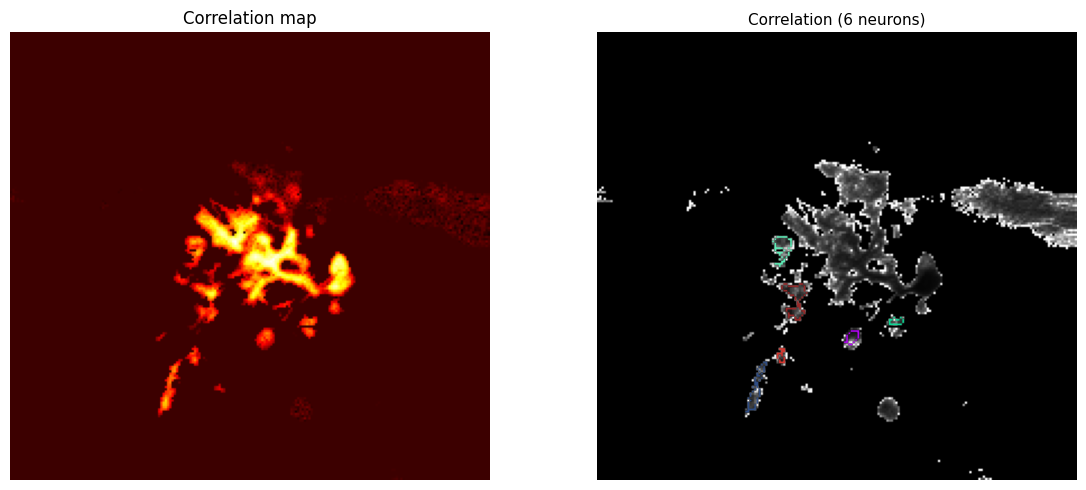

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].imshow(corr_map, cmap="hot")
axes[0].set_title("Correlation map")

from src.visualize import plot_segmentation_overlay
mean_proj_dff = np.mean(dff, axis=0)
plot_segmentation_overlay(mean_proj_dff, labels_corr, title="Correlation", ax=axes[1])

for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()

## 3b. Segmentation - Cellpose

A pretrained deep learning model (CPSAM) that detects cell bodies from a single 2D image. It predicts per-pixel gradient flows toward cell centers, then groups pixels into cell instances.

We feed it the raw mean projection (not dF/F), because Cellpose relies on cell morphology shape and brightness not temporal activity.

**Key Finding**: detects neurons based on shape, regardless of whether they fired.

In [9]:
from src.segment.cellpose_seg import segment_cellpose

mean_proj_raw = np.mean(stack, axis=0)
labels_cellpose = segment_cellpose(mean_proj_raw)

  Cellpose segmentation: 4 cells detected (diameter=auto)


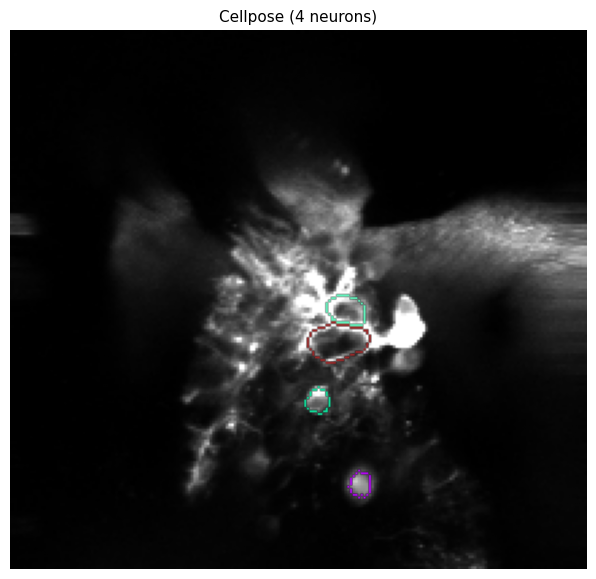

In [10]:
fig, ax = plt.subplots(figsize=(8, 7))
plot_segmentation_overlay(mean_proj_raw, labels_cellpose, title="Cellpose", ax=ax)
plt.show()

## 4. Trace Extraction

For each detected neuron (ROI), we extract its **activity trace**: the mean fluorescence across all pixels in that ROI at every time point. This gives us a 1D signal showing when the neuron was active.

In [11]:
from src.traces import extract_traces

print("Correlation ROIs:")
traces_corr = extract_traces(dff, labels_corr)

print("Cellpose ROIs:")
traces_cellpose = extract_traces(dff, labels_cellpose)

Correlation ROIs:
  Extracted 6 traces, 360 time points each
Cellpose ROIs:
  Extracted 4 traces, 360 time points each


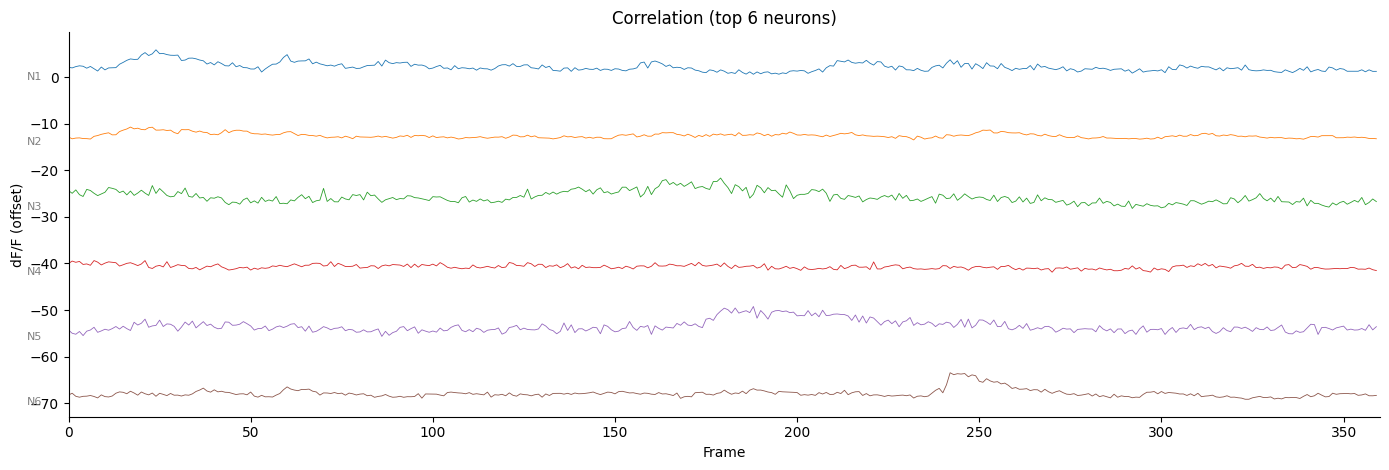

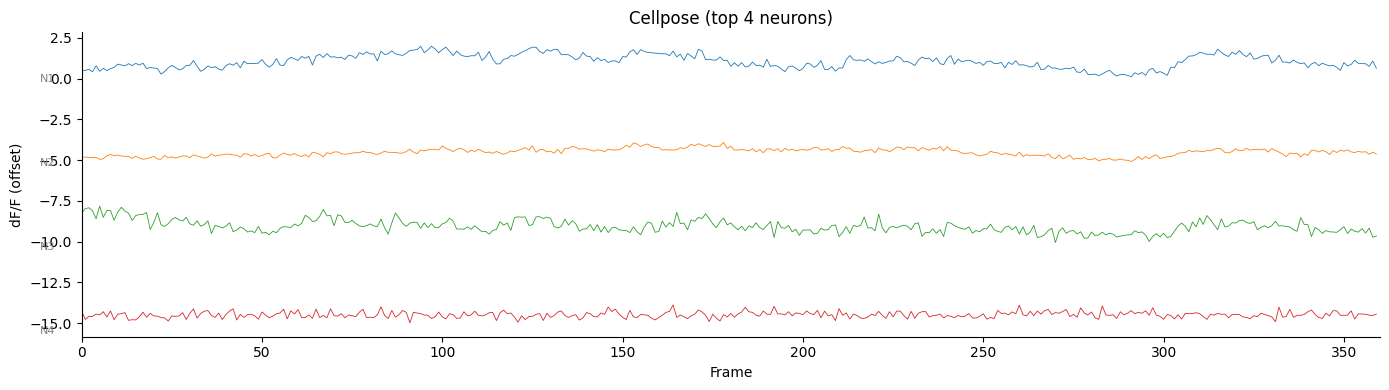

In [12]:
from src.visualize import plot_traces

fig = plot_traces(traces_corr, n=10, title="Correlation")
plt.show()

fig = plot_traces(traces_cellpose, n=10, title="Cellpose")
plt.show()

## 5. Comparison

| | Correlation | Cellpose |
|---|---|---|
| **Input** | Full video (T, H, W) | Single 2D image |
| **Finds** | Temporally active neurons | Morphologically visible cells |
| **Strength** | Robust to poor image quality | Detects silent neurons too |
| **Weakness** | Misses inactive neurons | Misses neurons with unclear boundaries |

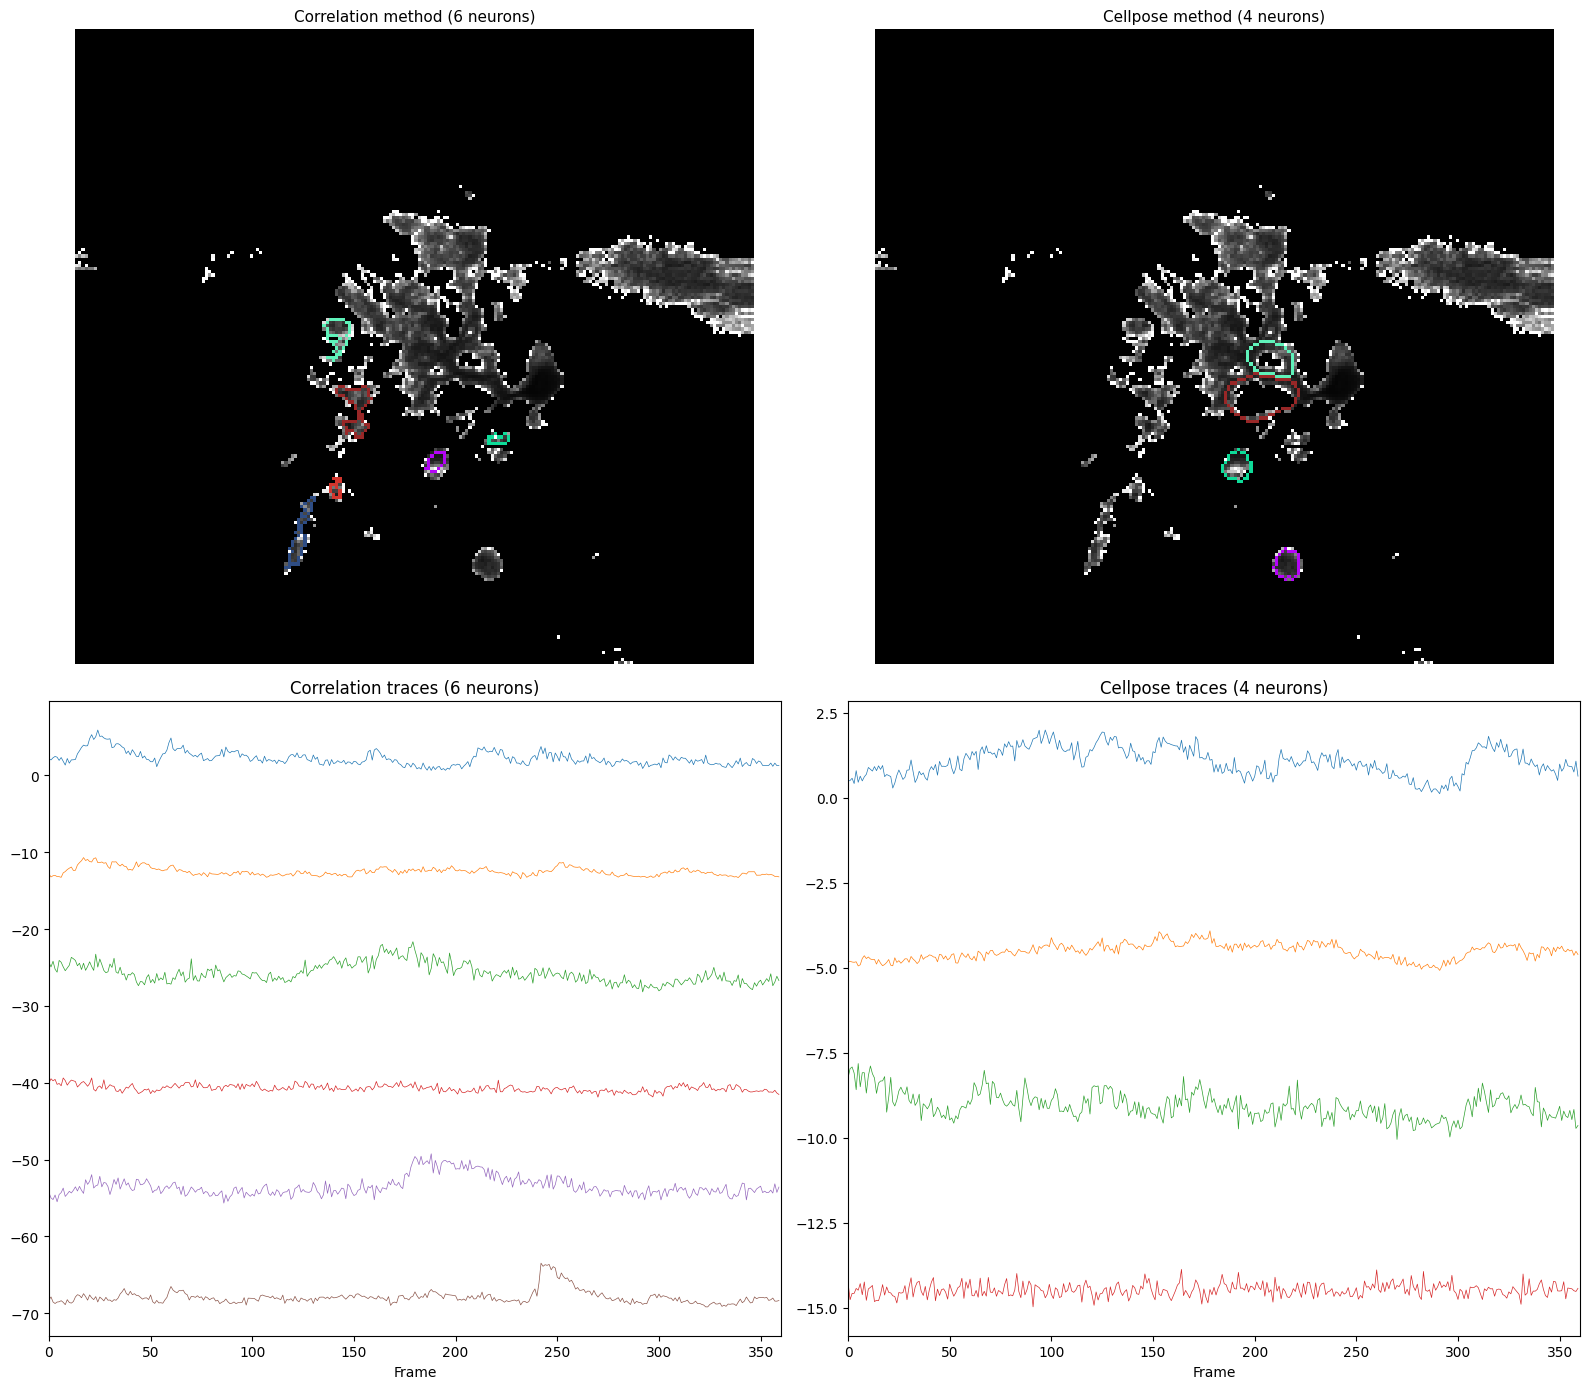

Correlation: 6 neurons
Cellpose:    4 neurons


In [13]:
from src.visualize import plot_comparison

fig = plot_comparison(mean_proj_dff, labels_corr, labels_cellpose,
                      traces_corr, traces_cellpose)
plt.show()

print(f"Correlation: {labels_corr.max()} neurons")
print(f"Cellpose:    {labels_cellpose.max()} neurons")